# Question 5, task 2

Diffusion is a technique for *generating* new images. In the diffusion process, we begin with random pixels and repeatedly remove "noise" from the image until we are left with an image we recognize. Ideally, the process would look something like the following: A cat on a bike slowly appears from random noise.

![](https://www.rtealwitter.com/deeplearning2023/images/noise-to-image.png)

Of course, removing such noise from an image is ostensibly a difficult task: How does the model know what noise to remove at each step? And how do we get training data? The key observation of diffusion is that, while going from noise to an image is challenging, going from an image to noise is quite easy: If we begin the process with a real image we already have, then we can add random noise to the image until the result becomes unrecognizable.

![](https://www.rtealwitter.com/deeplearning2023/images/image-to-noise.png)

Operationally, we provide one noisy image and train the model to predict the noise that was last added to it. Let's formulize the process in our three step recipe for machine learning:

1. **Model**. The model is an architecture that takes in a noisy image and predicts what noise was last applied.

2. **Loss**. The loss is the difference between the predicted noise and the actual noise. Of course, since we added the noise to the image, we actually do know what noise was last added and directly compare it to the prediction. We'll use the mean squared difference between the two as our loss criterion.

3. **Optimizer**. As usual, we run gradient descent on the parameter space of the model to minimize the loss.

In this lab, we will train a diffusion model on the MNIST data set. After getting a sense for how diffusion works, we will load pretrained models for *stable diffusion* and run them on prompts of your choice.



## Diffusion on MNIST

We will build a diffusion model on the relatively simpler data set of handwritten images.

As usual, we will load several helpful libraries.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F

### MNIST

The MNIST data set consists of $28 \times 28$ black-and-white images with handwritten digits. We will download the training set and count the number of images in the data set.

In [2]:
# we use FashionMNIST with the same normalization as the original demo
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  
])

train_data = torchvision.datasets.FashionMNIST(
    root="dataset",
    train=True,
    download=True,
    transform=transform,
)

print(f"There are {len(train_data)} images in the training set!")


There are 60000 images in the training set!


Since there are 60k images in the training set, we'll need a way to train on *batches* of them. For this purpose, we'll use the pytorch `DataLoader` and specify a batch size of 512 (we love powers of two and it [may help](https://stackoverflow.com/questions/44483233/is-using-batch-size-as-powers-of-2-faster-on-tensorflow) with parallelization).

In [3]:
batch_size = 512 

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size)

Before we begin building the architecture, let's take a look at the images in the data set.

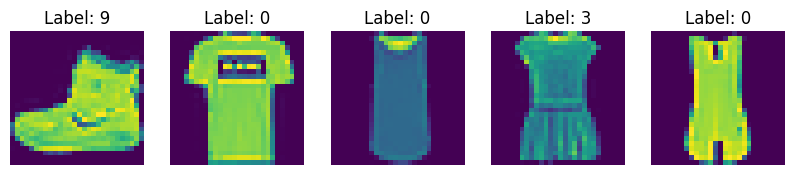

In [4]:
images, labels = next(iter(train_loader)) # load from the dataloader

plt.figure(figsize=(10,4))
for index in np.arange(0,5):
  plt.subplot(1,5,index+1)
  plt.axis('off')
  plt.title(f'Label: {labels[index].item()}')
  plt.imshow(images[index].squeeze().numpy())

As promised, we have handwritten digits that resemble numbers. As a sanity check, what is the shape of `images` as defined above?

In [5]:
# Check that the shape of images makes sense.
# (batch_size, 1, 28, 28)
images.shape

torch.Size([512, 1, 28, 28])

The first step of diffusion is to generate the training data. We'll draw the random noise from the normal distribution. However, we'll have to choose the standard deviation of the noise and how many steps of noise to apply. In order to choose appropriate values, let's plot what the noising process does.

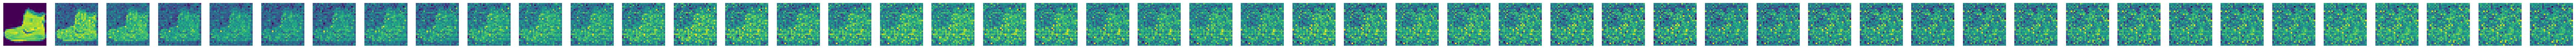

In [6]:
images, labels = next(iter(train_loader))
noisy_images = images

# The two hyperparameters we are choosing.
sigma = .35 # standard deviation
noise_steps = 50 # 10 # 20 # number of steps we apply noise

plt.figure(figsize=(noise_steps * 2, 10))
for i in range(noise_steps):
  # Draw noise from a normal distribution with standard deviation sigma.
  noise = torch.normal(0, sigma, images.shape) 
  plt.subplot(1,noise_steps,i+1)
  plt.imshow(noisy_images[0].squeeze())
  plt.axis('off')
  # Add the noise to the image.
  noisy_images = noise + noisy_images

After playing with the hyperparemeters, I set `sigma`=.35 and `noise_steps`=20. I chose these values with the following considerations in mind:

* Since the diffusion process will begin with noise, it's important that the training data includes noisy images that look like noise (i.e. no indication of the starting image).

* Simultaneously, there should be lots of images where the starting image is somewhat apparent. In this way, we train the model to remove noise both on images that look like noise *and* images that somewhat resemble the underlying image.

Of course, there are lots of other hyperparameter pairs that satisfy these constraints and you are welcome to explore for them.

### Architecture

Training a diffusion model is particularly finicky. To make this model work, there are several hacks that I employed:

* The output of the diffusion model is normalized to have mean 0 and standard deviation `sigma`. The reasoning is that this makes the output more closely resemble noise so we can make the training process faster.

* In addition to the image, the model takes in the number of noise steps that have been applied to the image. This gives it information on how much noise it should expect. Intuitively, this makes its task easier since the noise it removes should depend on how much noise has been added.

* The model takes in the label of the image. This extra information guides it through the diffusion process: for example, removing noise from a 9 is a different task than removing noise from a 7.

I found that each of these additions was necessary to training a successful diffusion model efficiently. If you are feeling adventurous, you're welcome to try removing these additions and/or adding your own.

Let's begin by defining the normalization function. We're simplying going to subtract the mean, divide by the standard deviation, and multiply by `sigma`. However, because we are applying this operation to each image separately in a batch, we need to be slightly careful about the dimensions.

In [7]:
def normalize(x, sigma):
  # x is (batch_size, 28*28)
  mean = x.mean(dim=-1).view(-1, 1)
  # mean is (batch_size, 1) i.e. a different mean for each image
  std = x.std(dim=-1).view(-1,1)
  # std is (batch_size, 1) i.e. a different standard deviation for each image
  return (x-mean) / std * sigma

We're now ready to define the diffusion architecture. Note that we will pass in they hyperparameters `sigma` and `noise_steps` when we initialize the model. In addition, we will actually use a very simple two layer linear architecture. There will be about $(28 \cdot 28)^2 = 614656$ parameters which, since the images are small, is relatively mangeable. When we pass them in, we will [one-hot](https://en.wikipedia.org/wiki/One-hot) the amount of noise and the number of labels.

In [8]:
class Diffuser(nn.Module):
  def __init__(self, sigma, noise_steps):
    super(Diffuser, self).__init__()
    # Recall the input is the image,
    # the amount of noise applied (this will be one-hot encoded),
    # and the number of labels (this will also be one-hot encoded).
    self.layers = nn.Sequential(
      nn.Linear(28*28+noise_steps+10, 28*28),
      nn.ReLU(),
      nn.Linear(28*28, 28*28)
    )
    self.sigma = sigma
    self.noise_steps = noise_steps
 
  def forward(self, images, noise_level, labels):
    # Convert image from (batch_size, 1, 28, 28) to (batch_size, 28*28) using .view
    images = images.view(-1, 28*28)
    # Combine the image with the noise level and labels.
    # We one hot encode both using F.one_hot
    noise_level_encoding = F.one_hot(
        torch.tensor([noise_level]*images.shape[0]), num_classes = self.noise_steps
    ).to(device)
    labels_encoding = F.one_hot(labels, num_classes = 10).to(device)
    # Concatenate the three inputs in a batch of long vectors    
    x = torch.cat((images, noise_level_encoding, labels_encoding), 1)
    # The shape should now be (batch_size, 28*28+noise_steps+10) 
    # Feed the input through the layers.
    x = self.layers(x)
    # Normalize x using our normalize function
    x = normalize(x, self.sigma)
    # Reformat the output so it is (batch_size, 1, 28, 28) using .view
    x = x.view(-1, 1, 28, 28)
    return x

Now we are ready to initialize the model, optimizer, and criterion. So that we can train faster on the GPU, we will also define the device. To use the GPU on colab, make sure that Runtime > Change runtime type > Hardware accelerator is on GPU.

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = Diffuser(sigma, noise_steps).to(device)
optimizer = torch.optim.Adam(model.parameters(), 1)
criterion = nn.MSELoss()

We'll also want to sample noise efficiently on the GPU. To do this, we'll define a normal distribution with standard deviation `sigma`.

In [10]:
# Define unit_normal as an instance of torch.distributions.Normal
# and put its parameters (loc and scale) on the device.
unit_normal = torch.distributions.Normal(0, sigma)
unit_normal.loc = unit_normal.loc.to(device)
unit_normal.scale = unit_normal.scale.to(device)

So that we can visualize how the model is doing during training, let's write an evaluation function. The function will sample random noise and, guided by each label, use the model to repeatedly remove noise from the image for `noise_steps` iterations.

The initial noise will be sampled from a mean-centered normal distribution with standard deviation `sigma` `noise_steps`^1/2. (This is because of a [special property](https://en.wikipedia.org/wiki/Sum_of_normally_distributed_random_variables#:~:text=This%20means%20that%20the%20sum,squares%20of%20the%20standard%20deviations) of the sum of normal distributions.)

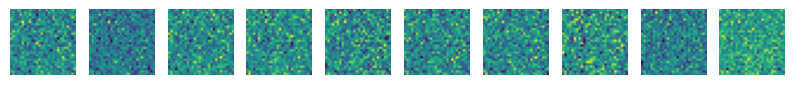

In [11]:
def evaluate(model, noise_steps):
  # Sample noisy images.
  noisy_images = unit_normal.sample((10,1,28,28))*np.sqrt(noise_steps)
  # Initialize labels.
  labels = torch.tensor([i for i in range(10)])
  plt.figure(figsize=(10, 5))
  # Remove noise from the images.
  for noise_step in range(noise_steps):    
    # Why is noise level defined as below?
    noise_level = noise_steps - noise_step - 1
    # Apply the model without keeping track of gradient.
    with torch.no_grad():
      noise = model(noisy_images, noise_level, labels)
    noisy_images -= noise
  # Plot the resulting images.
  for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(noisy_images[i].cpu().squeeze())
    plt.axis('off')
  plt.show()

evaluate(model, noise_steps)

As we expect, the untrained model just produces noise. Let's see if we can do any better after training.

### Training

We will now train the model! For each batch in each epoch, we will try different noise levels in a random order (this is to randomize the gradient descent updates). Using the variance trick for normal distributions, we can sample a noisy image after `noise_level` steps of `sigma` noise simply by sampling from a distribution with standard deviation `sigma` `noise_level`^1/2.

/tmp/ipykernel_12349/2016066999.py:10: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  less_noisy = images + unit_normal.sample(images.shape) * np.sqrt(noise_level)


Epoch: 0 	 Loss: 1231.3812972977757


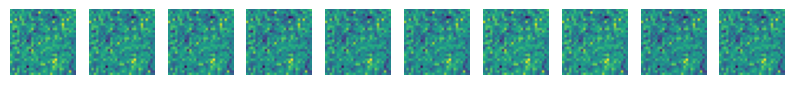

Epoch: 1 	 Loss: 1163.321765087545


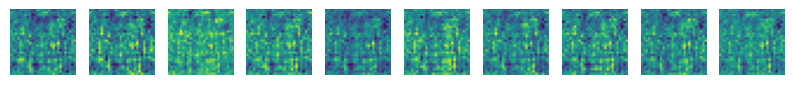

Epoch: 2 	 Loss: 1145.0065943077207


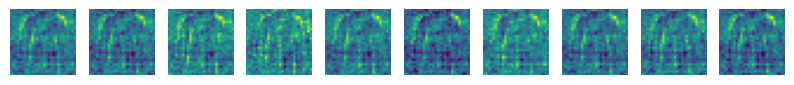

Epoch: 3 	 Loss: 1134.1569546163082


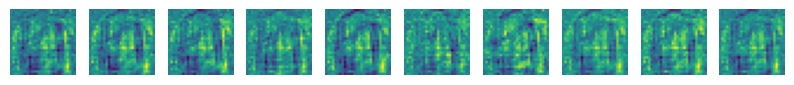

Epoch: 4 	 Loss: 1128.6117053553462


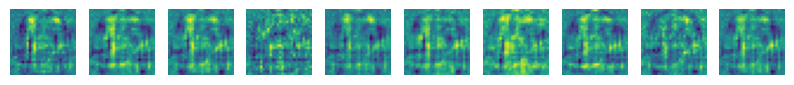

Epoch: 5 	 Loss: 1125.169148594141


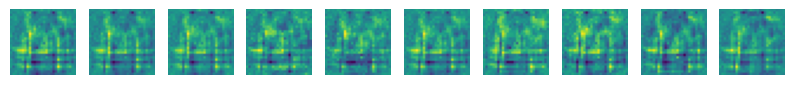

Epoch: 6 	 Loss: 1121.0954132378101


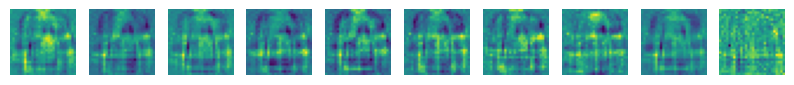

Epoch: 7 	 Loss: 1118.875018041581


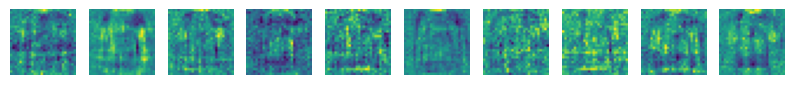

Epoch: 8 	 Loss: 1117.4245959371328


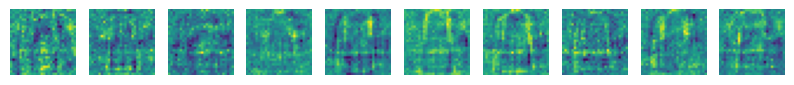

Epoch: 9 	 Loss: 1115.762124210596


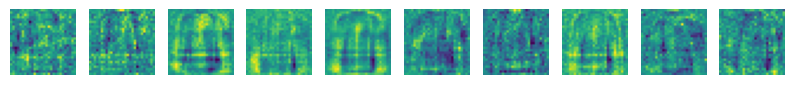

Epoch: 10 	 Loss: 1114.8530773185194


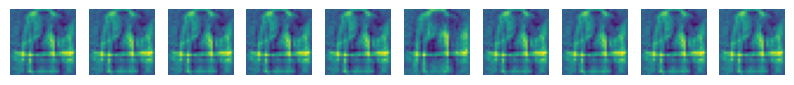

Epoch: 11 	 Loss: 1113.6817731149495


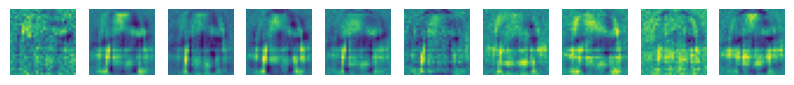

Epoch: 12 	 Loss: 1112.8650268428028


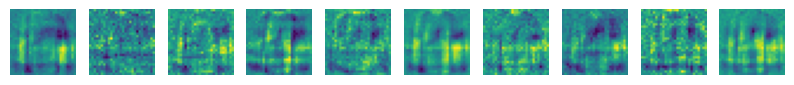

Epoch: 13 	 Loss: 1111.4586107097566


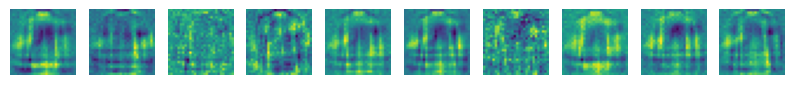

Epoch: 14 	 Loss: 1111.2240524739027


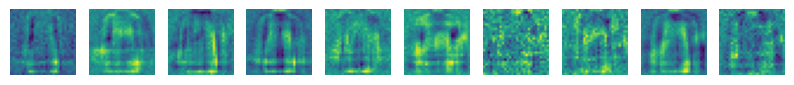

Epoch: 15 	 Loss: 1110.6576165109873


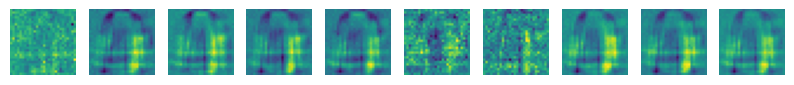

Epoch: 16 	 Loss: 1109.5690386928618


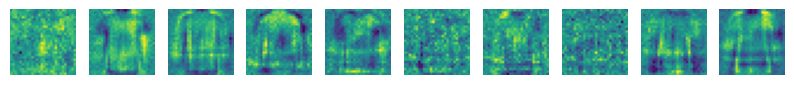

Epoch: 17 	 Loss: 1109.4898927249014


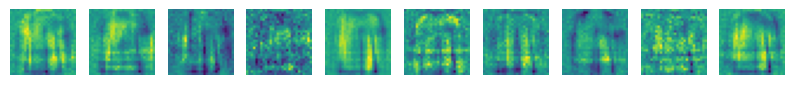

Epoch: 18 	 Loss: 1109.2166919186711


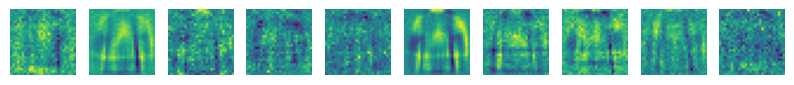

Epoch: 19 	 Loss: 1108.240076430142


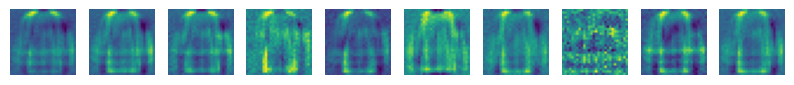

Epoch: 20 	 Loss: 1107.765610139817


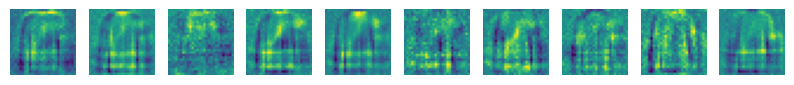

Epoch: 21 	 Loss: 1107.4098211303353


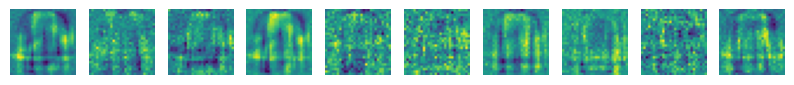

Epoch: 22 	 Loss: 1107.1070240549743


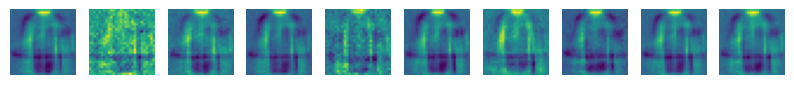

Epoch: 23 	 Loss: 1106.6857964135706


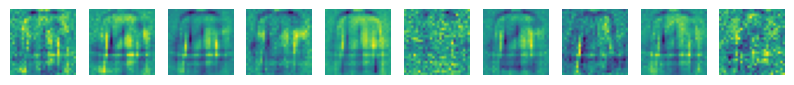

Epoch: 24 	 Loss: 1106.3886991888285


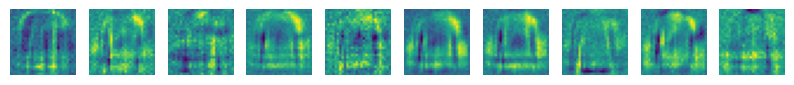

In [12]:
num_epochs = 25
losses = [] # to plot later
for epoch in range(num_epochs):
  epoch_loss = 0
  for images, labels in train_loader:
    # Put the images on the device.
    images = images.to(device)
    for noise_level in torch.randperm(noise_steps):
      # Build the less noisy image using the variance trick for normal distributions.
      less_noisy = images + unit_normal.sample(images.shape) * np.sqrt(noise_level)
      # Generate one more step of noise (standard deviation sigma).
      one_step_noise = unit_normal.sample(images.shape)
      # Generate the next noisy image.
      more_noisy = less_noisy + one_step_noise 
      # Use the model to predict the noise using more_noisy, noise_level, and labels.
      output = model(more_noisy, noise_level, labels)
      # Compute the loss and update.
      # The loss is simply the mean squared difference.
      loss = criterion(output, one_step_noise)
      # Zero the gradient of the optimizer.
      optimizer.zero_grad()
      # Backpropagate.
      loss.backward()
      # And take a step :)
      optimizer.step() 

      epoch_loss += loss.item()
  # We will print out the loss for each epoch.
  print(f'Epoch: {epoch} \t Loss: {epoch_loss}')
  losses.append(epoch_loss)  # store the loss for plotting later
  # And call our evaluate function to see any progress.
  evaluate(model, noise_steps)

We may have to squint but, if we the training worked successfully, we can see generated images with each digit! This is pretty impressive for 7 minutes of training on a free GPU.

Of course, you may want to see what some more powerful models can accomplish. The second part of this lab uses a pretrained model for stable diffusion.

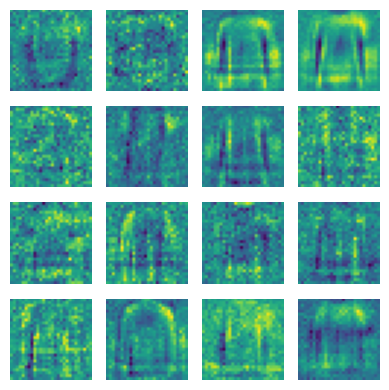

In [13]:
def sample_grid_4x4(model, noise_steps, device):
    model.eval()
    num_samples = 16

    noisy_images = unit_normal.sample((num_samples, 1, 28, 28)).to(device) * np.sqrt(noise_steps)
    labels = torch.randint(low=0, high=10, size=(num_samples,), device=device)

    with torch.no_grad():
        for noise_step in range(noise_steps):
            noise_level = noise_steps - noise_step - 1
            noise = model(noisy_images, noise_level, labels)
            noisy_images -= noise

    imgs = noisy_images.cpu()

    plt.figure(figsize=(4, 4))
    for i in range(num_samples):
        plt.subplot(4, 4, i + 1)
        plt.imshow(imgs[i].squeeze())
        plt.axis("off")
    plt.tight_layout()
    plt.show()
    
sample_grid_4x4(model, noise_steps, device)


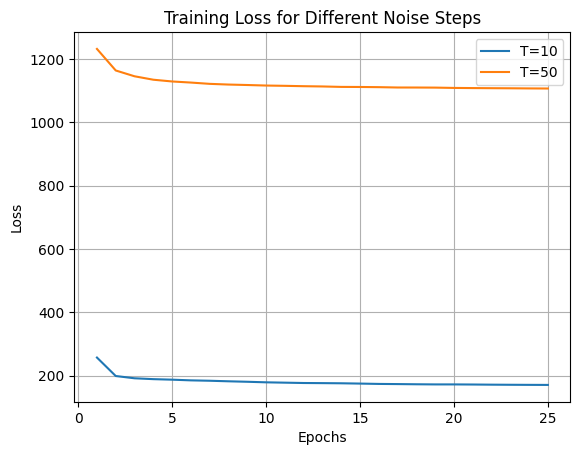

In [17]:
# plot our losses of 2 ablations
t_eq_10_loss = [256.9336574971676, 198.6199280768633, 191.46125500649214, 188.72468574345112, 187.066617064178, 184.87767131626606, 183.67048458755016, 181.94572341442108, 180.4449626132846, 178.69688818231225, 177.6158941499889, 176.54016139358282, 176.15467726066709, 175.66081048175693, 174.72094211354852, 173.62896271049976, 173.1334640532732, 172.5426711589098, 172.10114013776183, 172.10561986640096, 171.77583622932434, 171.29040184989572, 170.9464967995882, 170.6840508878231, 170.49087914824486]

t_eq_50_loss = [1231.3812972977757, 1163.321765087545, 1145.0065943077207, 1134.1569546163082, 1128.6117053553462, 1125.169148594141, 1121.0954132378101, 1118.875018041581, 1117.4245959371328, 1115.762124210596, 1114.8530773185194, 1113.6817731149495, 1112.8650268428028, 1111.4586107097566, 1111.2240524739027, 1110.6576165109873, 1109.5690386928618, 1109.4898927249014, 1109.2166919186711, 1108.240076430142, 1107.765610139817, 1107.4098211303353, 1107.1070240549743, 1106.6857964135706, 1106.3886991888285]

plt.plot(range(1,26), t_eq_10_loss, label='T=10')
plt.plot(range(1,26), t_eq_50_loss, label='T=50')
plt.xlabel('Epochs')   
plt.ylabel('Loss')
plt.title('Training Loss for Different Noise Steps')
plt.legend()
plt.grid()
plt.show()
